різниця к мінс/ фаззі с мінс


In [2]:
# Імпорт необхідних бібліотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

import skfuzzy as fuzz

In [3]:
# Налаштування для графіків
sns.set_theme(style="whitegrid", palette="muted", color_codes=True)

In [4]:
df = pd.read_csv('calories.csv')

# Оглянемо дані
print("Розмір даних:", df.shape)
display(df.head())

Розмір даних: (15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [5]:
# Конвертуємо Gender у числовий формат (male -> 0, female -> 1)
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])  # male=1, female=0

# Видаляємо стовпець User_ID (не потрібен для кластеризації)
df = df.drop(columns=['User_ID'])

# Перевіряємо розмір даних
print("Розмір даних:", df.shape)
display(df.head())

# Конвертуємо в NumPy масив для роботи з ML-алгоритмами
X = df.values

# Стандартизація даних
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Розмір даних: (15000, 8)


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,0,27,154.0,58.0,10.0,81.0,39.8,35.0


In [6]:
n_clusters = 3  # для Iris

# ---- K-Means ----
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)
score_kmeans = silhouette_score(X_scaled, labels_kmeans)
print("K-Means silhouette score:", score_kmeans)

K-Means silhouette score: 0.27609986578600765


In [7]:
# ---- Fuzzy C-Means ----
# Для skfuzzy дані потрібно транспонувати (ознаки - рядки)
X_t = X_scaled.T

# Параметри для FCM
m = 2.0  # показник нечіткості
error = 0.005
maxiter = 1000

# Виконання Fuzzy C-Means кластеризації
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_t, c=n_clusters, m=m, error=error, maxiter=maxiter, init=None, seed=42
)

# Отримання "жорсткого" розбиття: вибір кластера з найбільшою мірою членства
labels_fcm = np.argmax(u, axis=0)
score_fcm = silhouette_score(X_scaled, labels_fcm)
print("Fuzzy C-Means silhouette score:", score_fcm)

Fuzzy C-Means silhouette score: 0.2804041795575085


In [8]:
# ---- Gaussian Mixture Models (GMM) ----
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(X_scaled)
# Отримання м'яких (ймовірнісних) призначень і перетворення їх на "жорсткі"
labels_gmm = gmm.predict(X_scaled)
score_gmm = silhouette_score(X_scaled, labels_gmm)
print("GMM silhouette score:", score_gmm)

GMM silhouette score: 0.2522372810657528


Відсоток поясненої варіації: [0.45123806 0.33014507]


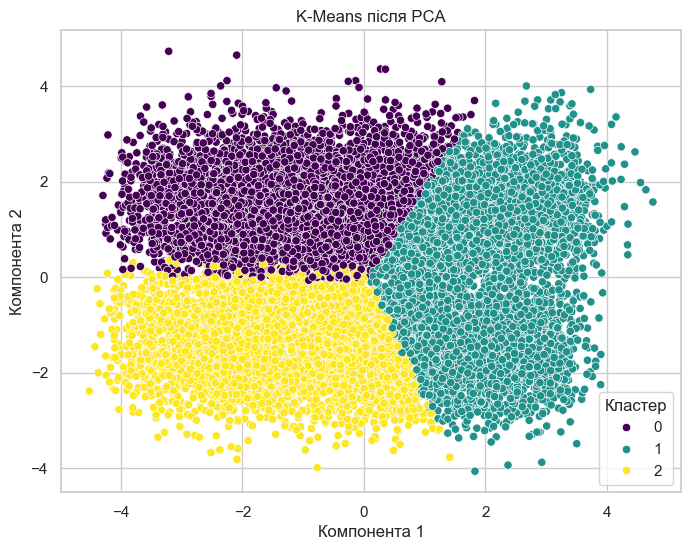

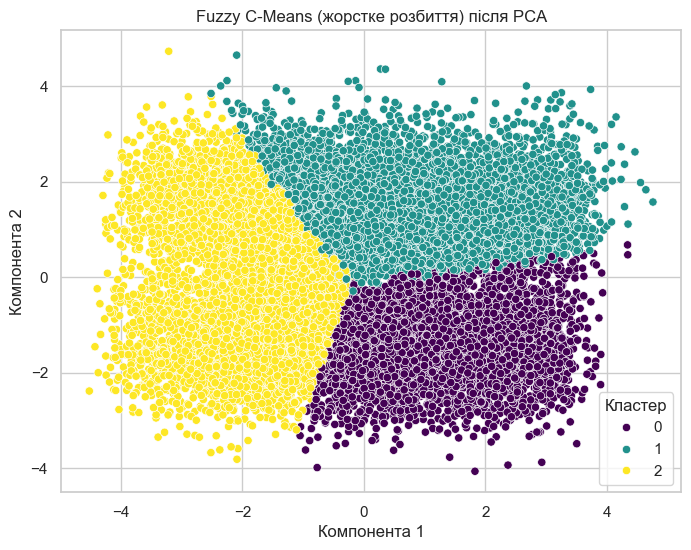

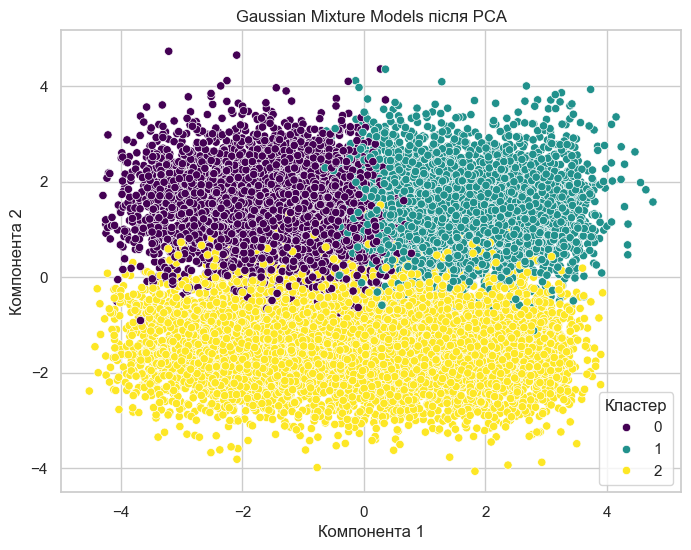

In [103]:
# Зменшення розмірності до 2 компонент за допомогою PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Відсоток поясненої варіації:", pca.explained_variance_ratio_)

# Функція для побудови графіка кластеризації
def plot_clusters(X, labels, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="viridis", )
    plt.title(title)
    plt.xlabel("Компонента 1")
    plt.ylabel("Компонента 2")
    plt.legend(title="Кластер")
    plt.show()

# Побудова графіків для кожного алгоритму
plot_clusters(X_pca, labels_kmeans, "K-Means після PCA")
plot_clusters(X_pca, labels_fcm, "Fuzzy C-Means (жорстке розбиття) після PCA")
plot_clusters(X_pca, labels_gmm, "Gaussian Mixture Models після PCA")


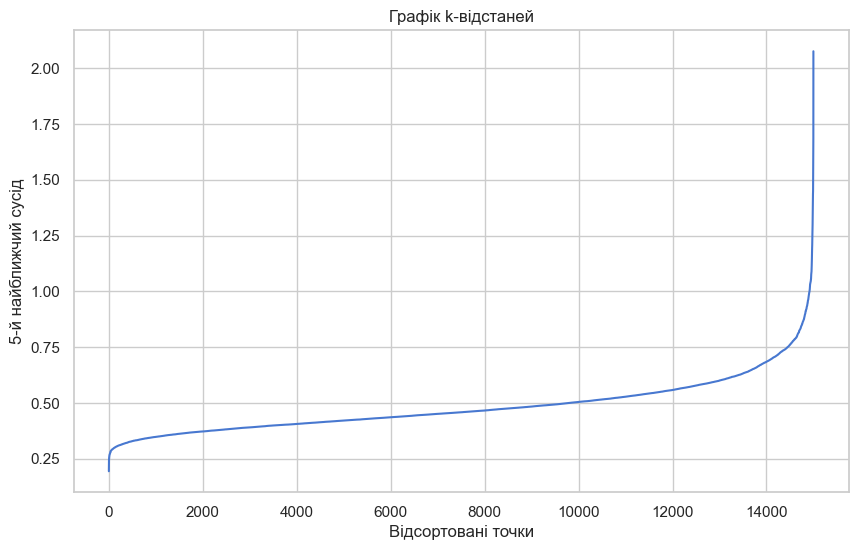

In [22]:
# Пошук оптимального eps за допомогою графіка k-відстаней
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Сортуємо відстані та будуємо графік
distances = np.sort(distances[:, min_samples - 1])
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('Графік k-відстаней')
plt.xlabel('Відсортовані точки')
plt.ylabel(f'{min_samples}-й найближчий сусід')
plt.grid(True)
plt.show()



In [60]:
# Обране значення eps (визначаємо за "переломом" на графіку)
eps = 1.5  # Це значення може змінюватись після аналізу графіка

# Запуск DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_scaled)

# Кількість знайдених кластерів (не враховуючи шумові точки -1)
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
print("DBSCAN кластерів:", n_clusters_dbscan)

# Виведення кількості об'єктів у кожному кластері у зручному форматі
cluster_counts = {int(k): int(v) for k, v in zip(unique, counts)}
print("Кількість об'єктів у кожному кластері:", cluster_counts)


DBSCAN кластерів: 2
Кількість об'єктів у кожному кластері: {-1: 1, 0: 7446, 1: 7553}


In [61]:
# Перевіряємо наявність кластерів перед обчисленням оцінок
if n_clusters_dbscan > 1:
    # Оцінка Silhouette (без урахування шуму)
    mask = labels_dbscan != -1
    score_dbscan_no_noise = silhouette_score(X_scaled[mask], labels_dbscan[mask])
    print("DBSCAN silhouette score (без шуму):", score_dbscan_no_noise)
    
    # Оцінка Silhouette (з урахуванням шуму)
    score_dbscan_with_noise = silhouette_score(X_scaled, labels_dbscan)
    print("DBSCAN silhouette score (з шумом):", score_dbscan_with_noise)

    # Davies-Bouldin Index (без шуму)
    db_index_no_noise = davies_bouldin_score(X_scaled[mask], labels_dbscan[mask])
    print("DBSCAN Davies-Bouldin Index (без шуму):", db_index_no_noise)
    
    # Davies-Bouldin Index (з шумом)
    db_index_with_noise = davies_bouldin_score(X_scaled, labels_dbscan)
    print("DBSCAN Davies-Bouldin Index (з шумом):", db_index_with_noise)
    
    # Calinski-Harabasz Index (без шуму)
    ch_index_no_noise = calinski_harabasz_score(X_scaled[mask], labels_dbscan[mask])
    print("DBSCAN Calinski-Harabasz Index (без шуму):", ch_index_no_noise)
    
    # Calinski-Harabasz Index (з шумом)
    ch_index_with_noise = calinski_harabasz_score(X_scaled, labels_dbscan)
    print("DBSCAN Calinski-Harabasz Index (з шумом):", ch_index_with_noise)
else:
    print("DBSCAN не знайшов достатньої кількості кластерів для обчислення оцінок.")

DBSCAN silhouette score (без шуму): 0.2701325061729984
DBSCAN silhouette score (з шумом): 0.2502418697926645
DBSCAN Davies-Bouldin Index (без шуму): 1.5625149040469433
DBSCAN Davies-Bouldin Index (з шумом): 1.1860201190713966
DBSCAN Calinski-Harabasz Index (без шуму): 5403.448984626302
DBSCAN Calinski-Harabasz Index (з шумом): 2704.990661969014


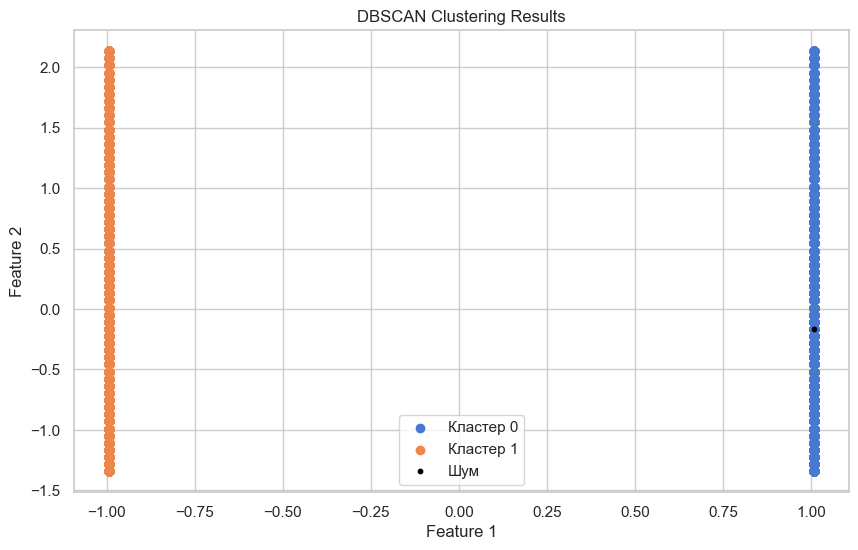

In [62]:
# Графік кластерів
plt.figure(figsize=(10, 6))

# Розділяємо класифікацію точок на шуми (-1) та інші кластери
unique_labels = set(labels_dbscan)
for label in unique_labels:
    label_mask = (labels_dbscan == label)
    if label == -1:  # Шуми
        plt.scatter(X_scaled[label_mask, 0], X_scaled[label_mask, 1], color='black', s=10, label="Шум")
    else:  # Кластери
        plt.scatter(X_scaled[label_mask, 0], X_scaled[label_mask, 1], label=f"Кластер {label}")

plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
from sklearn.decomposition import PCA

# Спочатку збережемо PCA на 2 компоненти
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Для 3D варіанту
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

In [65]:
explained_variance_2d = pca_2d.explained_variance_ratio_.sum() * 100
explained_variance_3d = pca_3d.explained_variance_ratio_.sum() * 100

print(f"2 компоненти пояснюють {explained_variance_2d:.2f}% варіації даних")
print(f"3 компоненти пояснюють {explained_variance_3d:.2f}% варіації даних")

2 компоненти пояснюють 78.14% варіації даних
3 компоненти пояснюють 90.82% варіації даних


In [106]:
# Функція для кластеризації
def perform_clustering(model, X, n_clusters=3):
    labels = model.fit_predict(X)
    if isinstance(model, DBSCAN):
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = "Недостатньо кластерів для оцінки"
    else:
        score = silhouette_score(X, labels)
    return labels, score

# Функція для візуалізації
def plot_clusters(X, labels, title, is_3d=False):
    plt.figure(figsize=(8, 6))
    if is_3d:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis')
        ax.set_title(title)
        ax.set_xlabel("PCA Component 1")
        ax.set_ylabel("PCA Component 2")
        ax.set_zlabel("PCA Component 3")
        fig.colorbar(scatter, ax=ax, label='Cluster')  # додано colorbar для 3D
    else:
        scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
        plt.title(title)
        plt.xlabel("PCA Component 1")
        plt.ylabel("PCA Component 2")
        plt.colorbar(scatter, label='Cluster')  # додано colorbar для 2D
    plt.show()


K-Means (2 компоненти) silhouette score: 0.393
K-Means (3 компоненти) silhouette score: 0.308


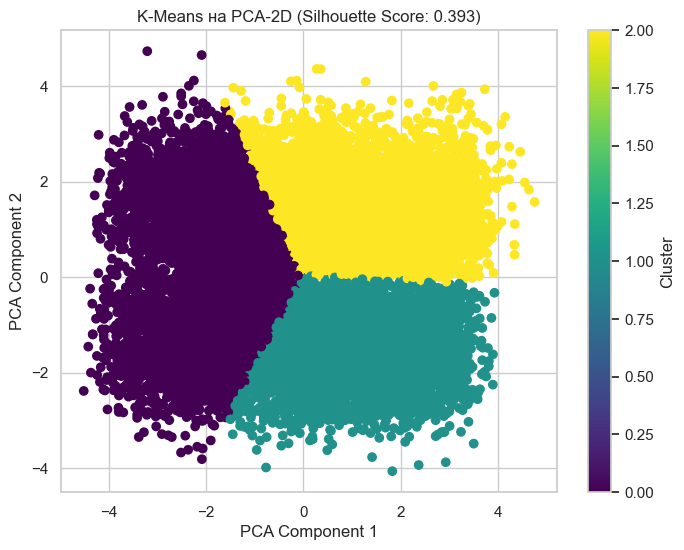

<Figure size 800x600 with 0 Axes>

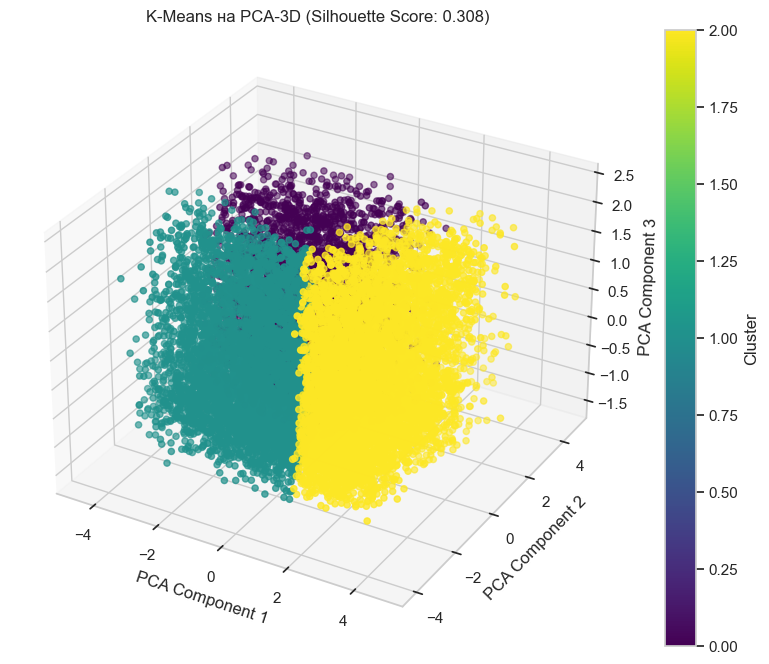

In [108]:
# 1. K-Means кластеризація
kmeans_2d = KMeans(n_clusters=3, random_state=42)
labels_kmeans_2d, score_kmeans_2d = perform_clustering(kmeans_2d, X_pca_2d)
print(f"K-Means (2 компоненти) silhouette score: {score_kmeans_2d:.3f}")

kmeans_3d = KMeans(n_clusters=3, random_state=42)
labels_kmeans_3d, score_kmeans_3d = perform_clustering(kmeans_3d, X_pca_3d)
print(f"K-Means (3 компоненти) silhouette score: {score_kmeans_3d:.3f}")

# Візуалізація для 2 компонент (PCA-2D) та 3 компонент (PCA-3D)
plot_clusters(X_pca_2d, labels_kmeans_2d, f"K-Means на PCA-2D (Silhouette Score: {score_kmeans_2d:.3f})")
plot_clusters(X_pca_3d, labels_kmeans_3d, f"K-Means на PCA-3D (Silhouette Score: {score_kmeans_3d:.3f})", is_3d=True)


DBSCAN (2 компоненти) silhouette score: Недостатньо кластерів для оцінки
DBSCAN (3 компоненти) silhouette score: Недостатньо кластерів для оцінки


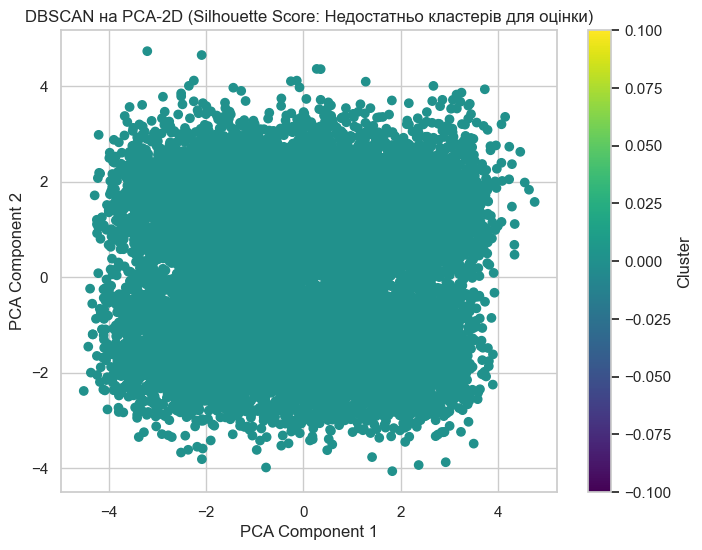

<Figure size 800x600 with 0 Axes>

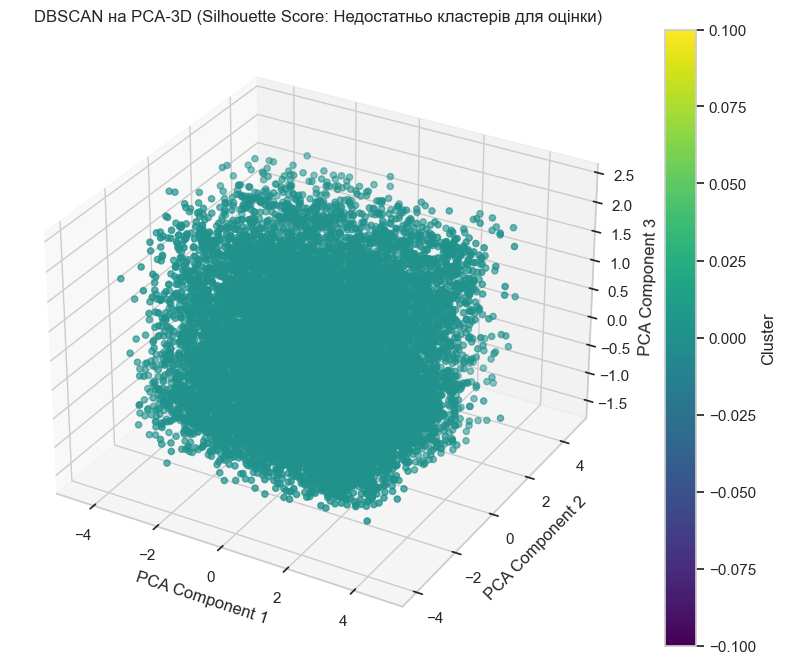

In [109]:
# 2. DBSCAN кластеризація
dbscan_2d = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan_2d, score_dbscan_2d = perform_clustering(dbscan_2d, X_pca_2d)
print(f"DBSCAN (2 компоненти) silhouette score: {score_dbscan_2d}")

dbscan_3d = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan_3d, score_dbscan_3d = perform_clustering(dbscan_3d, X_pca_3d)
print(f"DBSCAN (3 компоненти) silhouette score: {score_dbscan_3d}")

# Візуалізація для 2 компонент (PCA-2D) та 3 компонент (PCA-3D)
plot_clusters(X_pca_2d, labels_dbscan_2d, f"DBSCAN на PCA-2D (Silhouette Score: {score_dbscan_2d})")
plot_clusters(X_pca_3d, labels_dbscan_3d, f"DBSCAN на PCA-3D (Silhouette Score: {score_dbscan_3d})", is_3d=True)


GMM (2 компоненти) silhouette score: 0.388
GMM (3 компоненти) silhouette score: 0.272


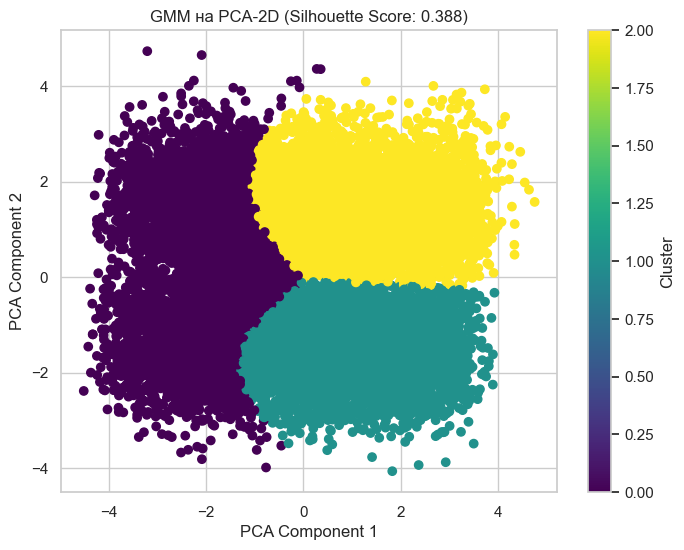

<Figure size 800x600 with 0 Axes>

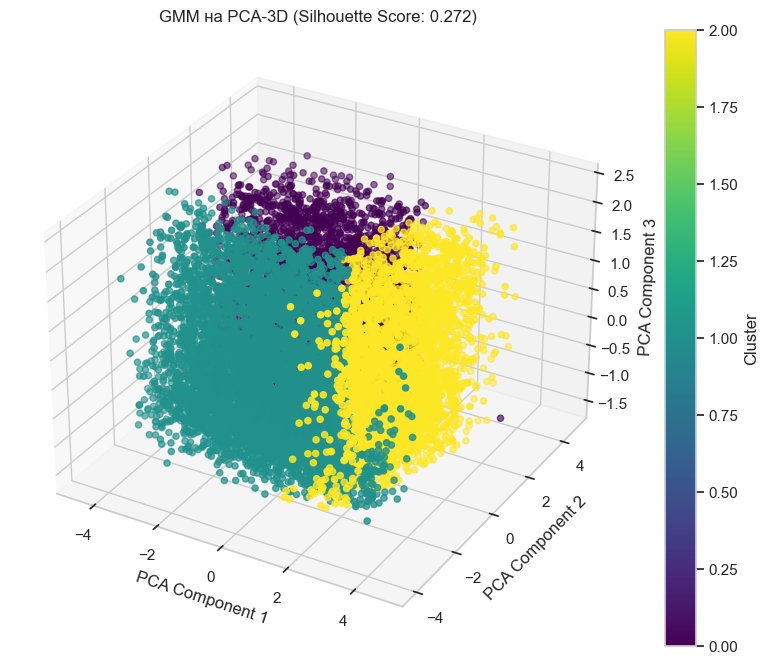

In [110]:
# 3. GMM (Gaussian Mixture Model) кластеризація
gmm_2d = GaussianMixture(n_components=3, random_state=42)
labels_gmm_2d, score_gmm_2d = perform_clustering(gmm_2d, X_pca_2d)
print(f"GMM (2 компоненти) silhouette score: {score_gmm_2d:.3f}")

gmm_3d = GaussianMixture(n_components=3, random_state=42)
labels_gmm_3d, score_gmm_3d = perform_clustering(gmm_3d, X_pca_3d)
print(f"GMM (3 компоненти) silhouette score: {score_gmm_3d:.3f}")

# Візуалізація для 2 компонент (PCA-2D) та 3 компонент (PCA-3D)
plot_clusters(X_pca_2d, labels_gmm_2d, f"GMM на PCA-2D (Silhouette Score: {score_gmm_2d:.3f})")
plot_clusters(X_pca_3d, labels_gmm_3d, f"GMM на PCA-3D (Silhouette Score: {score_gmm_3d:.3f})", is_3d=True)

Fuzzy C-Means (2 компоненти) silhouette score: 0.392
Fuzzy C-Means (3 компоненти) silhouette score: 0.316


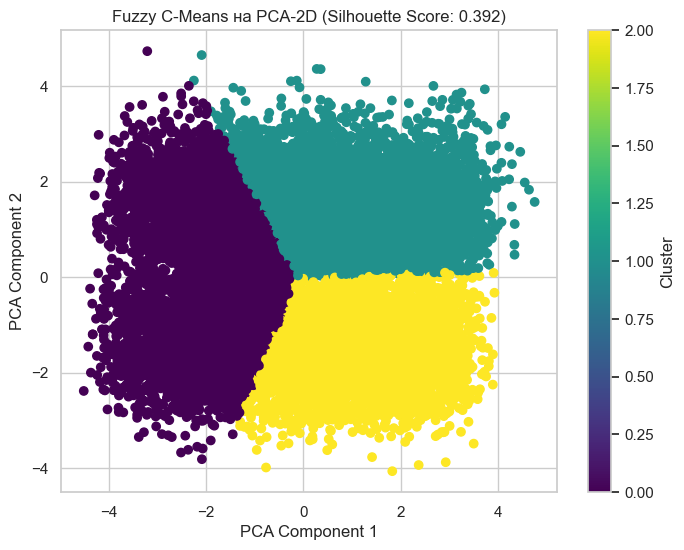

<Figure size 800x600 with 0 Axes>

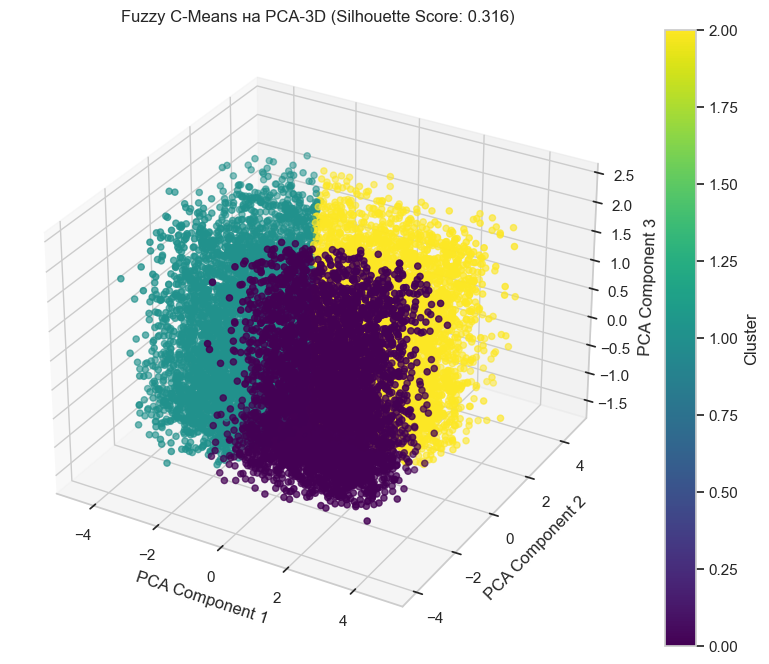

In [111]:
# 4. Fuzzy C-Means кластеризація
fcm_2d = fuzz.cluster.cmeans(X_pca_2d.T, 3, 2, error=0.005, maxiter=1000)
labels_fcm_2d = np.argmax(fcm_2d[1], axis=0)
score_fcm_2d = silhouette_score(X_pca_2d, labels_fcm_2d)
print(f"Fuzzy C-Means (2 компоненти) silhouette score: {score_fcm_2d:.3f}")

fcm_3d = fuzz.cluster.cmeans(X_pca_3d.T, 3, 2, error=0.005, maxiter=1000)
labels_fcm_3d = np.argmax(fcm_3d[1], axis=0)
score_fcm_3d = silhouette_score(X_pca_3d, labels_fcm_3d)
print(f"Fuzzy C-Means (3 компоненти) silhouette score: {score_fcm_3d:.3f}")

# Візуалізація для 2 компонент (PCA-2D) та 3 компонент (PCA-3D)
plot_clusters(X_pca_2d, labels_fcm_2d, f"Fuzzy C-Means на PCA-2D (Silhouette Score: {score_fcm_2d:.3f})")
plot_clusters(X_pca_3d, labels_fcm_3d, f"Fuzzy C-Means на PCA-3D (Silhouette Score: {score_fcm_3d:.3f})", is_3d=True)

In [74]:
# Зменшення розмірності до 4 компонент
pca_4d = PCA(n_components=4)
X_pca_4d = pca_4d.fit_transform(X_scaled)

# Зменшення розмірності до 5 компонент
pca_5d = PCA(n_components=5)
X_pca_5d = pca_5d.fit_transform(X_scaled)


In [75]:
# Пояснена варіація для 4 і 5 компонент
explained_variance_4d = pca_4d.explained_variance_ratio_.sum() * 100
explained_variance_5d = pca_5d.explained_variance_ratio_.sum() * 100

print(f"4 компоненти пояснюють {explained_variance_4d:.2f}% варіації даних")
print(f"5 компонент пояснюють {explained_variance_5d:.2f}% варіації даних")


4 компоненти пояснюють 94.88% варіації даних
5 компонент пояснюють 97.97% варіації даних


In [115]:
# Функція для кластеризації
def perform_clustering(model, X, n_clusters=3):
    labels = model.fit_predict(X)
    if isinstance(model, DBSCAN):
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = "Недостатньо кластерів для оцінки"
    else:
        score = silhouette_score(X, labels)
    return labels, score

# Функція для візуалізації
def plot_clusters(X, labels, title, is_3d=False):
    plt.figure(figsize=(8, 6))
    if is_3d:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis')
        ax.set_title(title)
        ax.set_xlabel("PCA Component 1")
        ax.set_ylabel("PCA Component 2")
        ax.set_zlabel("PCA Component 3")
        fig.colorbar(scatter, ax=ax, label='Cluster')
    else:
        scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
        plt.title(title)
        plt.xlabel("PCA Component 1")
        plt.ylabel("PCA Component 2")
        plt.colorbar(scatter, label='Cluster')
    plt.show()

K-Means (4 компоненти) silhouette score: 0.296
K-Means (5 компонент) silhouette score: 0.283


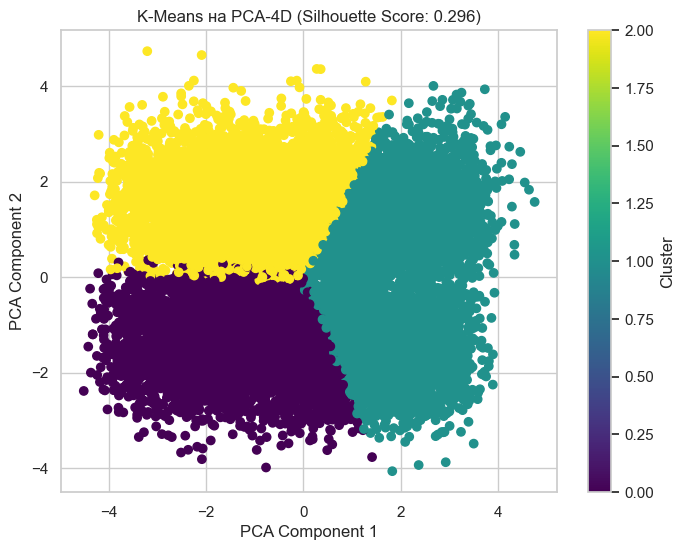

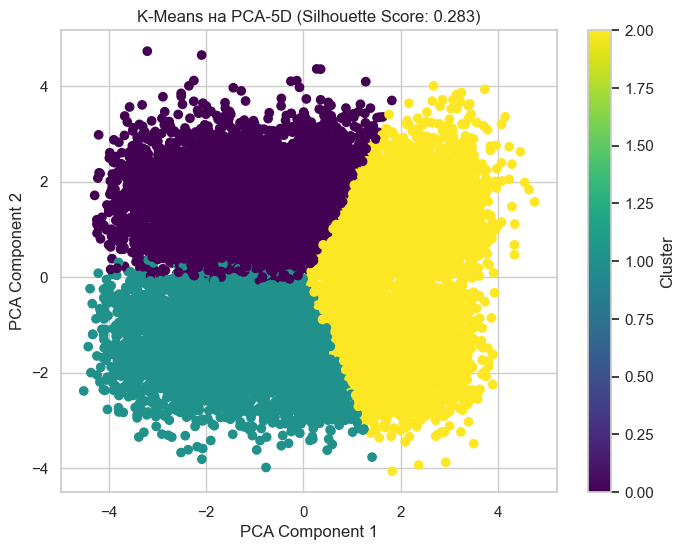

In [116]:
# 1. K-Means кластеризація
kmeans_4d = KMeans(n_clusters=3, random_state=42)
labels_kmeans_4d, score_kmeans_4d = perform_clustering(kmeans_4d, X_pca_4d)
print(f"K-Means (4 компоненти) silhouette score: {score_kmeans_4d:.3f}")

kmeans_5d = KMeans(n_clusters=3, random_state=42)
labels_kmeans_5d, score_kmeans_5d = perform_clustering(kmeans_5d, X_pca_5d)
print(f"K-Means (5 компонент) silhouette score: {score_kmeans_5d:.3f}")

# Візуалізація для 4 і 5 компонент
plot_clusters(X_pca_4d, labels_kmeans_4d, f"K-Means на PCA-4D (Silhouette Score: {score_kmeans_4d:.3f})")
plot_clusters(X_pca_5d, labels_kmeans_5d, f"K-Means на PCA-5D (Silhouette Score: {score_kmeans_5d:.3f})")


DBSCAN (4 компоненти) silhouette score: 0.28775648987169683
DBSCAN (5 компонент) silhouette score: 0.25555601399241423


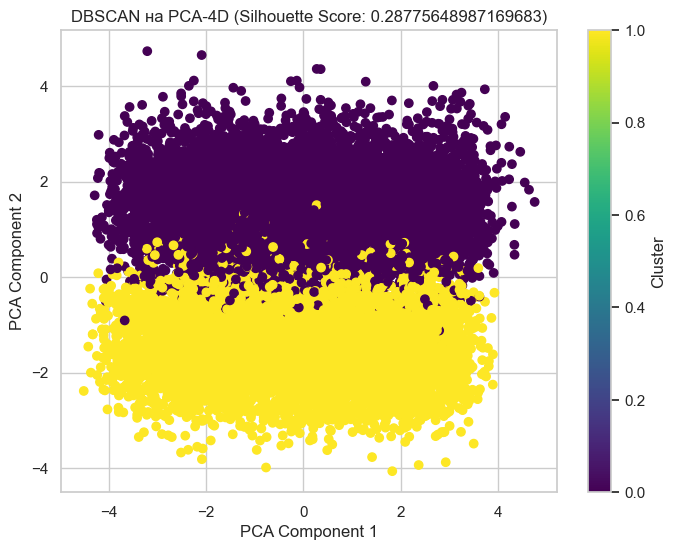

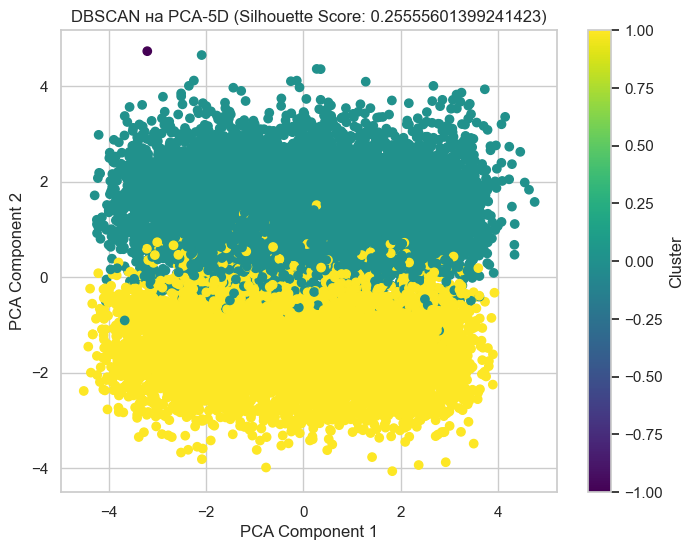

In [117]:
# 2. DBSCAN кластеризація
dbscan_4d = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan_4d, score_dbscan_4d = perform_clustering(dbscan_4d, X_pca_4d)
print(f"DBSCAN (4 компоненти) silhouette score: {score_dbscan_4d}")

dbscan_5d = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan_5d, score_dbscan_5d = perform_clustering(dbscan_5d, X_pca_5d)
print(f"DBSCAN (5 компонент) silhouette score: {score_dbscan_5d}")

# Візуалізація для 4 і 5 компонент
plot_clusters(X_pca_4d, labels_dbscan_4d, f"DBSCAN на PCA-4D (Silhouette Score: {score_dbscan_4d})")
plot_clusters(X_pca_5d, labels_dbscan_5d, f"DBSCAN на PCA-5D (Silhouette Score: {score_dbscan_5d})")


GMM (4 компоненти) silhouette score: 0.288
GMM (5 компонент) silhouette score: 0.277


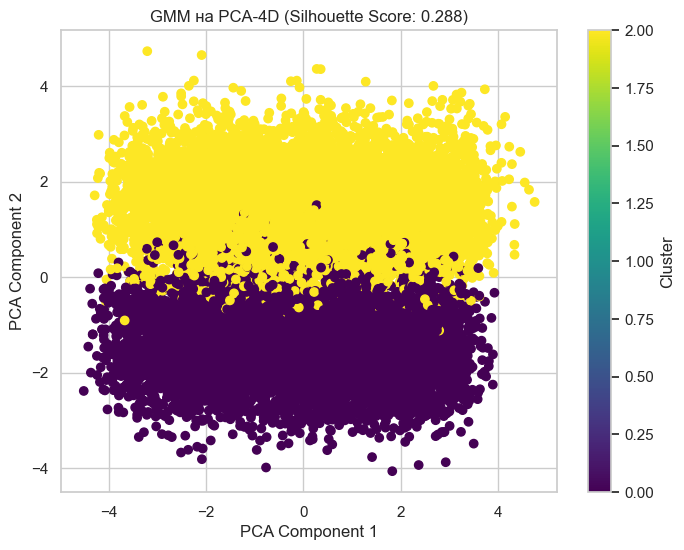

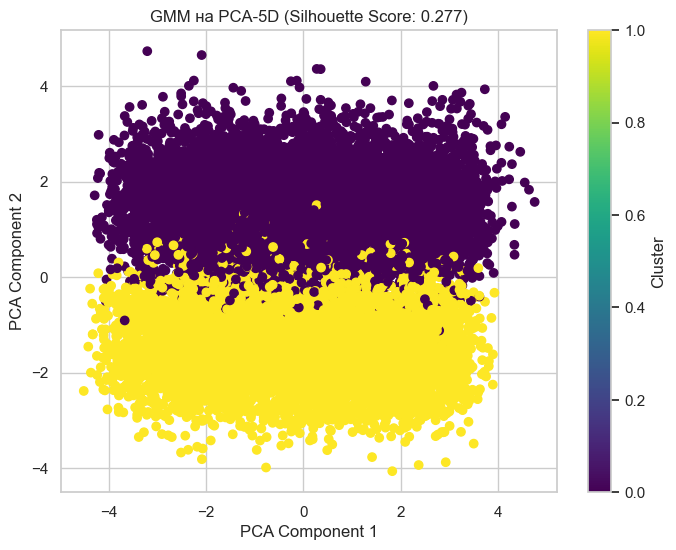

In [118]:
# 3. GMM (Gaussian Mixture Model) кластеризація
gmm_4d = GaussianMixture(n_components=3, random_state=42)
labels_gmm_4d, score_gmm_4d = perform_clustering(gmm_4d, X_pca_4d)
print(f"GMM (4 компоненти) silhouette score: {score_gmm_4d:.3f}")

gmm_5d = GaussianMixture(n_components=3, random_state=42)
labels_gmm_5d, score_gmm_5d = perform_clustering(gmm_5d, X_pca_5d)
print(f"GMM (5 компонент) silhouette score: {score_gmm_5d:.3f}")

# Візуалізація для 4 і 5 компонент
plot_clusters(X_pca_4d, labels_gmm_4d, f"GMM на PCA-4D (Silhouette Score: {score_gmm_4d:.3f})")
plot_clusters(X_pca_5d, labels_gmm_5d, f"GMM на PCA-5D (Silhouette Score: {score_gmm_5d:.3f})")


Fuzzy C-Means (4 компоненти) silhouette score: 0.303
Fuzzy C-Means (5 компонент) silhouette score: 0.289


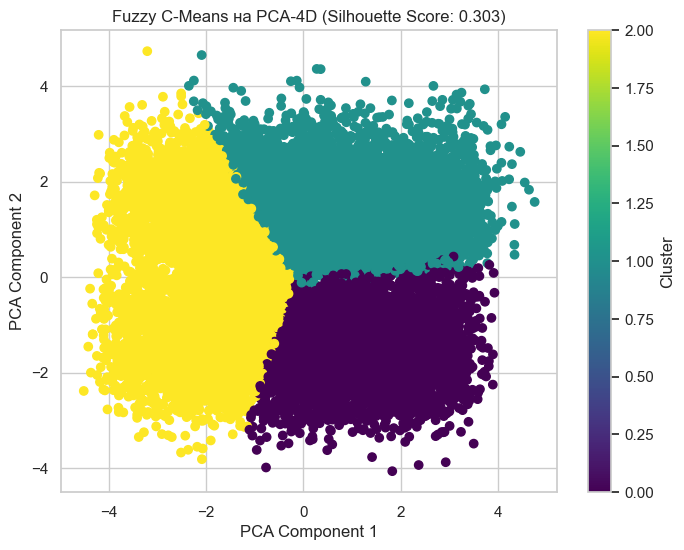

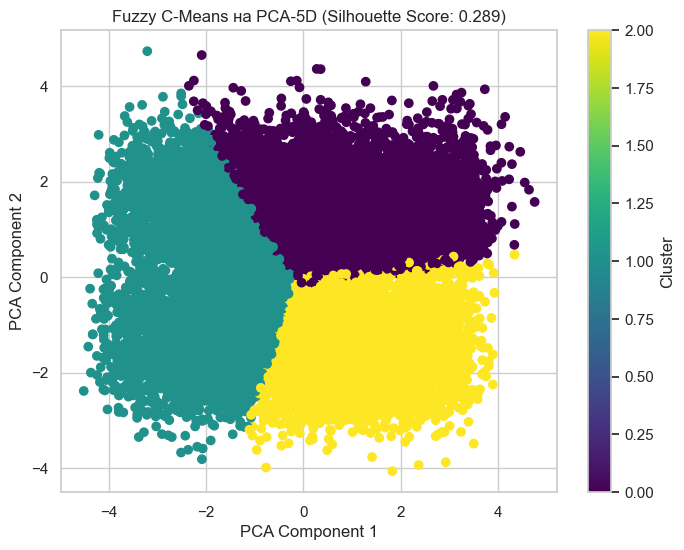

In [119]:
# 4. Fuzzy C-Means кластеризація
fcm_4d = fuzz.cluster.cmeans(X_pca_4d.T, 3, 2, error=0.005, maxiter=1000)
labels_fcm_4d = np.argmax(fcm_4d[1], axis=0)
score_fcm_4d = silhouette_score(X_pca_4d, labels_fcm_4d)
print(f"Fuzzy C-Means (4 компоненти) silhouette score: {score_fcm_4d:.3f}")

fcm_5d = fuzz.cluster.cmeans(X_pca_5d.T, 3, 2, error=0.005, maxiter=1000)
labels_fcm_5d = np.argmax(fcm_5d[1], axis=0)
score_fcm_5d = silhouette_score(X_pca_5d, labels_fcm_5d)
print(f"Fuzzy C-Means (5 компонент) silhouette score: {score_fcm_5d:.3f}")

# Візуалізація для 4 і 5 компонент
plot_clusters(X_pca_4d, labels_fcm_4d, f"Fuzzy C-Means на PCA-4D (Silhouette Score: {score_fcm_4d:.3f})")
plot_clusters(X_pca_5d, labels_fcm_5d, f"Fuzzy C-Means на PCA-5D (Silhouette Score: {score_fcm_5d:.3f})")

In [76]:
# 1. K-Means кластеризація на даних після PCA (4 компоненти)
kmeans_4d = KMeans(n_clusters=3, random_state=42)
labels_kmeans_4d = kmeans_4d.fit_predict(X_pca_4d)
score_kmeans_4d = silhouette_score(X_pca_4d, labels_kmeans_4d)
print(f"K-Means (4 компоненти) silhouette score: {score_kmeans_4d:.3f}")

# 2. K-Means кластеризація на даних після PCA (5 компонент)
kmeans_5d = KMeans(n_clusters=3, random_state=42)
labels_kmeans_5d = kmeans_5d.fit_predict(X_pca_5d)
score_kmeans_5d = silhouette_score(X_pca_5d, labels_kmeans_5d)
print(f"K-Means (5 компонент) silhouette score: {score_kmeans_5d:.3f}")

K-Means (4 компоненти) silhouette score: 0.296
K-Means (5 компонент) silhouette score: 0.283


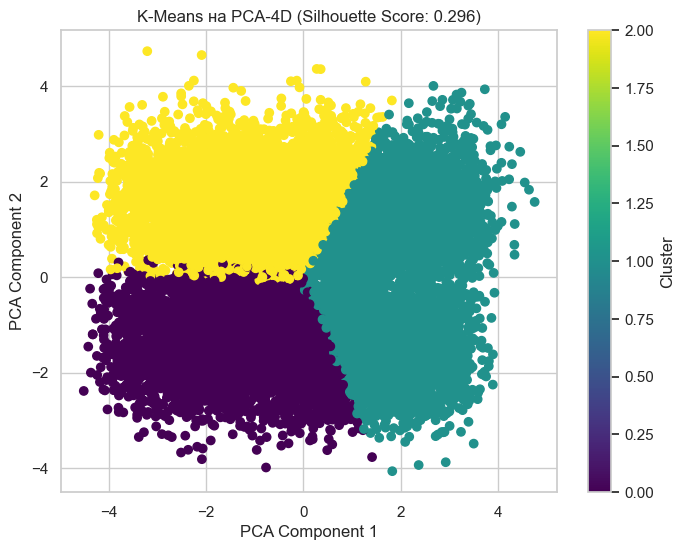

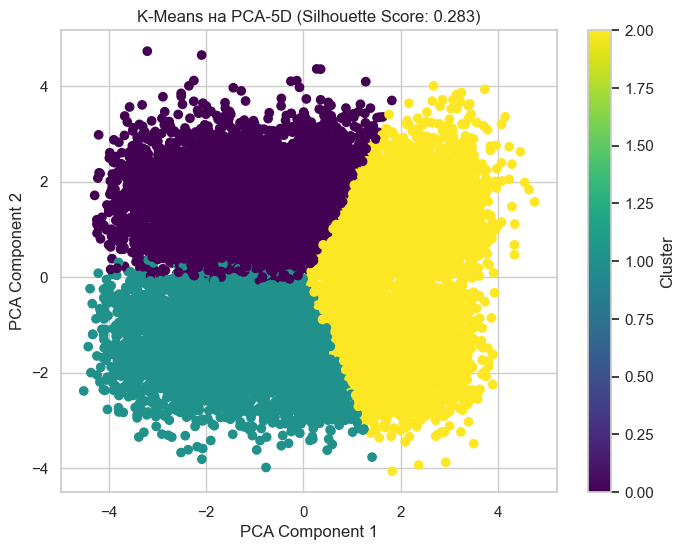

In [88]:
# Візуалізація K-Means на 4 компонентах (PCA-4D)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_4d[:, 0], X_pca_4d[:, 1], c=labels_kmeans_4d, cmap='viridis')
plt.title(f"K-Means на PCA-4D (Silhouette Score: {score_kmeans_4d:.3f})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

# Візуалізація K-Means на 5 компонентах (PCA-5D)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_5d[:, 0], X_pca_5d[:, 1], c=labels_kmeans_5d, cmap='viridis')
plt.title(f"K-Means на PCA-5D (Silhouette Score: {score_kmeans_5d:.3f})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

In [77]:
# 3. DBSCAN кластеризація на даних після PCA (4 компоненти)
dbscan_4d = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan_4d = dbscan_4d.fit_predict(X_pca_4d)
n_clusters_dbscan_4d = len(set(labels_dbscan_4d)) - (1 if -1 in labels_dbscan_4d else 0)
score_dbscan_4d = silhouette_score(X_pca_4d, labels_dbscan_4d) if n_clusters_dbscan_4d > 1 else "Недостатньо кластерів для оцінки"
print(f"DBSCAN (4 компоненти) silhouette score: {score_dbscan_4d}")

# 4. DBSCAN кластеризація на даних після PCA (5 компонент)
dbscan_5d = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan_5d = dbscan_5d.fit_predict(X_pca_5d)
n_clusters_dbscan_5d = len(set(labels_dbscan_5d)) - (1 if -1 in labels_dbscan_5d else 0)
score_dbscan_5d = silhouette_score(X_pca_5d, labels_dbscan_5d) if n_clusters_dbscan_5d > 1 else "Недостатньо кластерів для оцінки"
print(f"DBSCAN (5 компонент) silhouette score: {score_dbscan_5d}")

DBSCAN (4 компоненти) silhouette score: 0.28775648987169683
DBSCAN (5 компонент) silhouette score: 0.25555601399241423


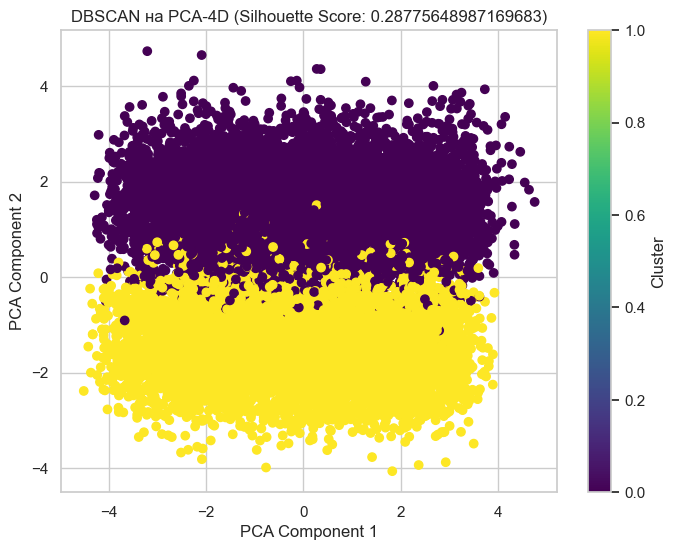

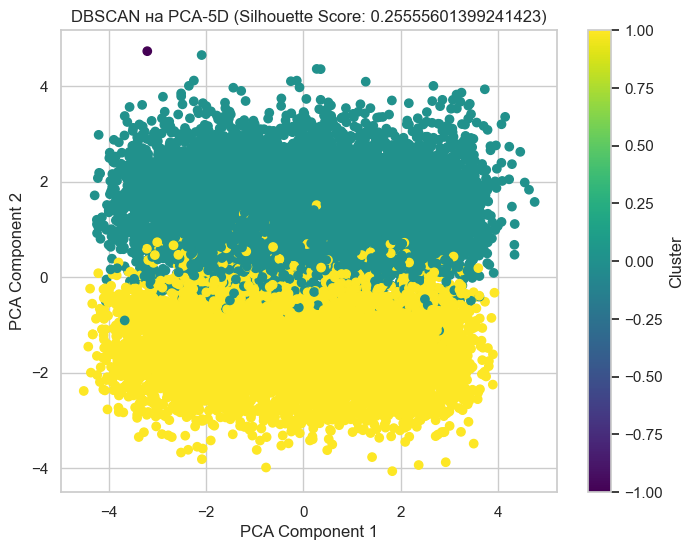

In [90]:
# Візуалізація DBSCAN на 4 компонентах (PCA-4D)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_4d[:, 0], X_pca_4d[:, 1], c=labels_dbscan_4d, cmap='viridis')
plt.title(f"DBSCAN на PCA-4D (Silhouette Score: {score_dbscan_4d})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

# Візуалізація DBSCAN на 5 компонентах (PCA-5D)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_5d[:, 0], X_pca_5d[:, 1], c=labels_dbscan_5d, cmap='viridis')
plt.title(f"DBSCAN на PCA-5D (Silhouette Score: {score_dbscan_5d})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

In [78]:
# 5. GMM (Gaussian Mixture Model) кластеризація на даних після PCA (4 компоненти)
gmm_4d = GaussianMixture(n_components=3, random_state=42)
labels_gmm_4d = gmm_4d.fit_predict(X_pca_4d)
score_gmm_4d = silhouette_score(X_pca_4d, labels_gmm_4d)
print(f"GMM (4 компоненти) silhouette score: {score_gmm_4d:.3f}")

# 6. GMM (Gaussian Mixture Model) кластеризація на даних після PCA (5 компонент)
gmm_5d = GaussianMixture(n_components=3, random_state=42)
labels_gmm_5d = gmm_5d.fit_predict(X_pca_5d)
score_gmm_5d = silhouette_score(X_pca_5d, labels_gmm_5d)
print(f"GMM (5 компонент) silhouette score: {score_gmm_5d:.3f}")

GMM (4 компоненти) silhouette score: 0.288
GMM (5 компонент) silhouette score: 0.277


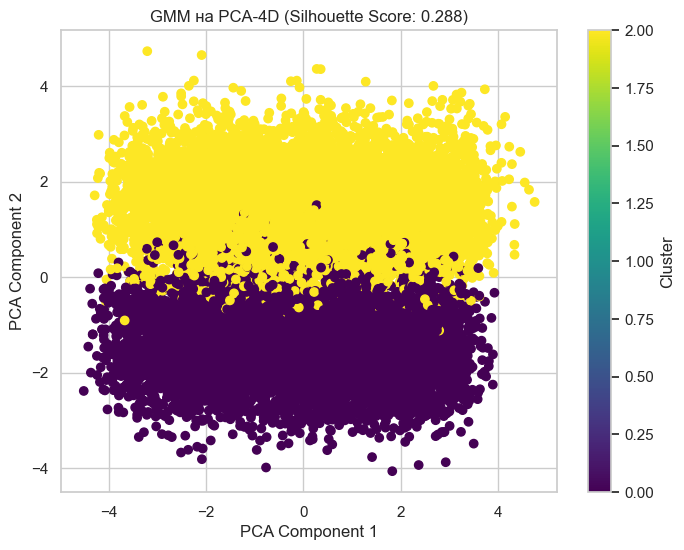

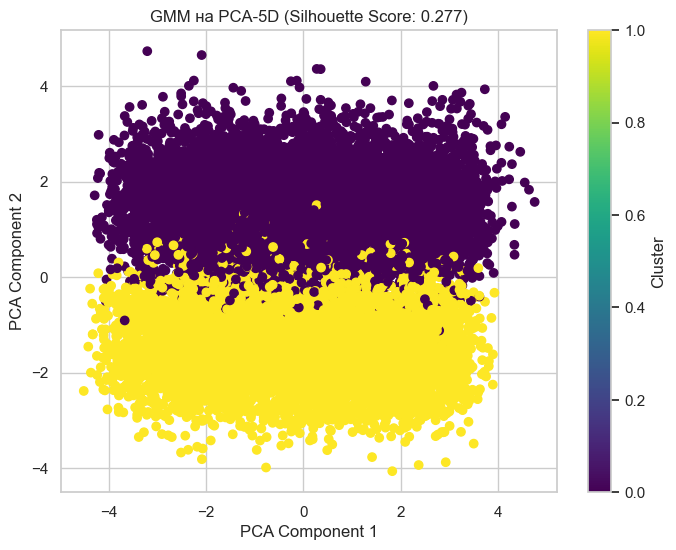

In [92]:
# Візуалізація GMM на 4 компонентах (PCA-4D)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_4d[:, 0], X_pca_4d[:, 1], c=labels_gmm_4d, cmap='viridis')
plt.title(f"GMM на PCA-4D (Silhouette Score: {score_gmm_4d:.3f})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

# Візуалізація GMM на 5 компонентах (PCA-5D)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_5d[:, 0], X_pca_5d[:, 1], c=labels_gmm_5d, cmap='viridis')
plt.title(f"GMM на PCA-5D (Silhouette Score: {score_gmm_5d:.3f})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

In [96]:
# 7. Fuzzy C-Means кластеризація на даних після PCA (4 компоненти)
fcm_4d = fuzz.cluster.cmeans(X_pca_4d.T, 3, 2, error=0.005, maxiter=1000)
labels_fcm_4d = np.argmax(fcm_4d[1], axis=0)
score_fcm_4d = silhouette_score(X_pca_4d, labels_fcm_4d)
print(f"Fuzzy C-Means (4 компоненти) silhouette score: {score_fcm_4d:.3f}")

# 8. Fuzzy C-Means кластеризація на даних після PCA (5 компонент)
fcm_5d = fuzz.cluster.cmeans(X_pca_5d.T, 3, 2, error=0.005, maxiter=1000)
labels_fcm_5d = np.argmax(fcm_5d[1], axis=0)
score_fcm_5d = silhouette_score(X_pca_5d, labels_fcm_5d)
print(f"Fuzzy C-Means (5 компонент) silhouette score: {score_fcm_5d:.3f}")

Fuzzy C-Means (4 компоненти) silhouette score: 0.303
Fuzzy C-Means (5 компонент) silhouette score: 0.289


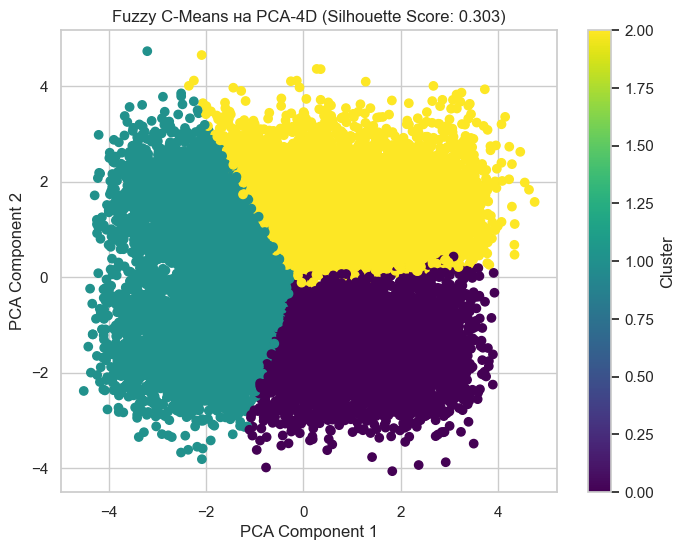

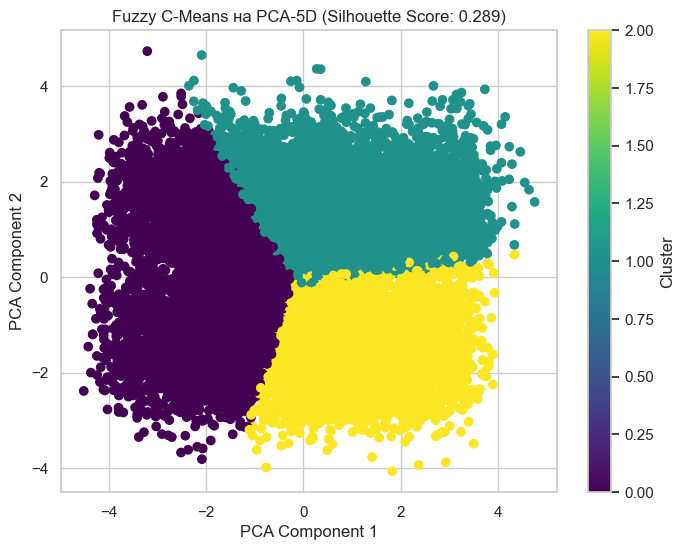

In [98]:
# Візуалізація Fuzzy C-Means на PCA-4D
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_4d[:, 0], X_pca_4d[:, 1], c=labels_fcm_4d, cmap='viridis')
plt.title(f"Fuzzy C-Means на PCA-4D (Silhouette Score: {score_fcm_4d:.3f})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

# Візуалізація Fuzzy C-Means на PCA-5D
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_5d[:, 0], X_pca_5d[:, 1], c=labels_fcm_5d, cmap='viridis')
plt.title(f"Fuzzy C-Means на PCA-5D (Silhouette Score: {score_fcm_5d:.3f})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

K-Means (вихідні дані) silhouette score: 0.276
K-Means (PCA 2 компоненти) silhouette score: 0.393


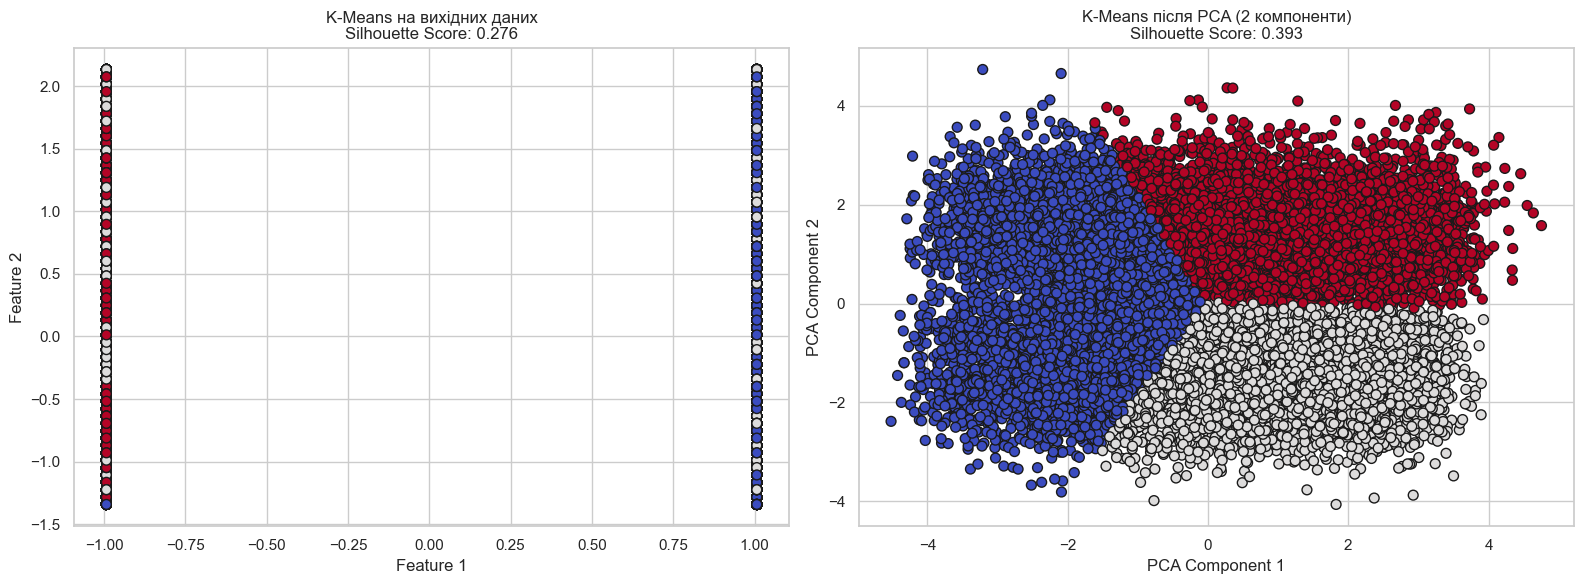

In [102]:
# 1. K-Means кластеризація на вихідних даних
kmeans_original = KMeans(n_clusters=3, random_state=42)
labels_kmeans_original = kmeans_original.fit_predict(X_scaled)

# 2. K-Means кластеризація на даних після PCA (2 компоненти)
kmeans_pca_2d = KMeans(n_clusters=3, random_state=42)
labels_kmeans_pca_2d = kmeans_pca_2d.fit_predict(X_pca_2d)

# Оцінка якості кластеризації (silhouette score)
score_kmeans_original = silhouette_score(X_scaled, labels_kmeans_original)
score_kmeans_pca_2d = silhouette_score(X_pca_2d, labels_kmeans_pca_2d)

# Виведення silhouette score
print(f"K-Means (вихідні дані) silhouette score: {score_kmeans_original:.3f}")
print(f"K-Means (PCA 2 компоненти) silhouette score: {score_kmeans_pca_2d:.3f}")

# Візуалізація порівняння K-Means до та після PCA

# Підготуємо графік
plt.figure(figsize=(16, 6))

# Вихідні дані для K-Means
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans_original, cmap='coolwarm', marker='o', edgecolors='k', s=50)
plt.title(f"K-Means на вихідних даних\nSilhouette Score: {score_kmeans_original:.3f}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Дані після PCA для K-Means
plt.subplot(1, 2, 2)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_kmeans_pca_2d, cmap='coolwarm', marker='o', edgecolors='k', s=50)
plt.title(f"K-Means після PCA (2 компоненти)\nSilhouette Score: {score_kmeans_pca_2d:.3f}")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Відображення графіка
plt.tight_layout()
plt.show()